In [ ]:
# ==============================================================
#  Stress Detection Pipelines - TF-IDF (1-4g) + LR
#  Stopwords are read from:
#     english_stopwords.txt  (one word per line)
#     chinese_stopwords.txt  (one word per line)
# ==============================================================

# If you need jieba in Colab:
# !pip -q install jieba joblib

import os, re, json, math, joblib, numpy as np, pandas as pd
from pathlib import Path
from typing import Any, Dict, List, Tuple

ENABLE_PLOTS = True  # set to False for speed

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# ----------------------- 1) Paths -----------------------
# If files are on Google Drive, mount and set DATA_ROOT accordingly:
from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final"

DATASETS = {
    "stress_detection": {
        "train": Path(DATA_ROOT) / "stress_detection_train.jsonl",
        "test":  Path(DATA_ROOT) / "stress_detection_test.jsonl",
    },
    "stress_level_prediction": {
        "train": Path(DATA_ROOT) / "stress_level_prediction_train.jsonl",
        "test":  Path(DATA_ROOT) / "stress_level_prediction_test.jsonl",
    },
}

MODELS_DIR = Path(DATA_ROOT) / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------- 2) Stopword files -----------------------
# Place these files (one token per line) under DATA_ROOT or provide absolute paths.
EN_SW_FILE = Path(DATA_ROOT) / "english_stopwords.txt"
CN_SW_FILE = Path(DATA_ROOT) / "chinese_stopwords.txt"

def load_stopwords(filepath: Path, lowercase: bool = False) -> set:
    if not filepath.exists():
        raise FileNotFoundError(f"Stopword file not found: {filepath}")
    words = []
    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            ln = line.strip()
            # Skip empty lines and comments
            if not ln or ln.startswith("#"):
                continue
            words.append(ln.lower() if lowercase else ln)
    return set(words)

EN_STOP = load_stopwords(EN_SW_FILE, lowercase=True)
CN_STOP = load_stopwords(CN_SW_FILE, lowercase=False)

# ----------------------- 3) Optional jieba -----------------------
try:
    import jieba  # type: ignore
    HAS_JIEBA = True
except Exception:
    HAS_JIEBA = False

# ----------------------- 4) Tokenizer -----------------------
CJK_RE = re.compile(r"[\u4e00-\u9fff]")
TOKEN_RE_EN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
FALLBACK_WORD_RE = re.compile(r"\w+")
NUM_PUNC_RE = re.compile(r"^[\W_]+$")

def mixed_tokenize(text: str) -> List[str]:
    text = str(text).strip()
    tokens: List[str] = []
    # English words
    en_words = [w.lower() for w in TOKEN_RE_EN.findall(text)]
    en_words = [w for w in en_words if w not in EN_STOP]
    tokens.extend(en_words)
    # Chinese words
    if CJK_RE.search(text):
        if HAS_JIEBA:
            cn_words = [w.strip() for w in jieba.cut(text, cut_all=False) if w.strip()]
        else:
            # character-level fallback
            cn_words = [ch for ch in text if CJK_RE.match(ch)]
        cn_words = [w for w in cn_words if w not in CN_STOP and not NUM_PUNC_RE.match(w)]
        tokens.extend(cn_words)
    # Fallback if empty
    if not tokens:
        tokens = [t for t in FALLBACK_WORD_RE.findall(text.lower()) if t not in EN_STOP]
    return tokens

# ----------------------- 5) Data loading -----------------------
def load_jsonl_df(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            try:
                rows.append(json.loads(ln))
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df.rename(columns={c: c.lower() for c in df.columns}, inplace=True)

    # Ensure "text"
    if "text" not in df.columns:
        for cand in ["body", "content", "selftext", "query"]:
            if cand in df.columns:
                df["text"] = df[cand].astype(str)
                break
    if "text" not in df.columns:
        df["text"] = df.apply(lambda r: json.dumps(r, ensure_ascii=False), axis=1)

    # Label normalization: High/Medium -> 1, Low -> 0, else numeric or prediction
    def normalize_label(row: Dict[str, Any]) -> int:
        lab = row.get("label", None)
        if isinstance(lab, str):
            lv = lab.strip().lower()
            if lv in {"high", "medium"}: return 1
            if lv in {"low"}: return 0
        if isinstance(lab, (int, float)): return int(lab)
        pred = row.get("prediction", None)
        if isinstance(pred, (int, float)): return int(pred)
        return 0

    df["label"] = df.apply(normalize_label, axis=1).astype(int)
    df["text"] = df["text"].astype(str)
    return df

# ----------------------- 6) Training + Eval -----------------------
def run_pipeline(
    dataset_id: str,
    train_path: Path,
    test_path: Path,
    max_features: int = 40000,
    min_df: int = 3,
    enable_plots: bool = True
) -> Dict[str, Any]:
    out: Dict[str, Any] = {"dataset": dataset_id}

    if not train_path.exists() or not test_path.exists():
        print(f"[{dataset_id}] Missing train or test file.")
        out["status"] = "MISSING"
        return out

    df_train = load_jsonl_df(train_path)
    df_test  = load_jsonl_df(test_path)
    if df_train.empty or df_test.empty:
        print(f"[{dataset_id}] Empty train or test.")
        out["status"] = "EMPTY"
        return out

    y_train = df_train["label"].values.astype(int)
    y_test  = df_test["label"].values.astype(int)

    vec = TfidfVectorizer(
        analyzer=mixed_tokenize,
        ngram_range=(1, 4),
        max_features=max_features,
        min_df=min_df,
        dtype=np.float32,
    )
    X_train = vec.fit_transform(df_train["text"])
    X_test  = vec.transform(df_test["text"])

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    # Eval
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*60)
    print(f"[{dataset_id}] TEST SET PERFORMANCE")
    print("="*60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nConfusion matrix:\n", cm)
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

    # Save artifacts
    save_dir = MODELS_DIR / dataset_id
    save_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(clf, save_dir / "classifier.joblib")
    joblib.dump(vec, save_dir / "tfidf_vectorizer.joblib")

    # Top features
    feature_names = np.array(vec.get_feature_names_out())
    coefs = clf.coef_[0]
    order = np.argsort(np.abs(coefs))[::-1]
    top_features = feature_names[order][:50]
    top_coefs = coefs[order][:50]

    top_df = pd.DataFrame({
        "feature": top_features,
        "coef": top_coefs,
        "abs_coef": np.abs(top_coefs)
    })
    top_df.to_csv(save_dir / "top_features.csv", index=False)
    top_df.to_json(save_dir / "top_features.json", orient="records", force_ascii=False, indent=2)

    # Plots
    if enable_plots:
        k = min(20, len(top_features))
        plt.figure(figsize=(10, 8))
        plt.barh(range(k), top_coefs[:k])
        plt.yticks(range(k), top_features[:k])
        plt.xlabel("Coefficient (positive = stress, negative = calm)")
        plt.title(f"{dataset_id}: Top {k} Features by |coef|")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(save_dir / "coefficient_importance.png", dpi=150, bbox_inches="tight")
        plt.close()

        TOP_K = min(10, len(feature_names))
        stress_idx = np.argsort(coefs)[-TOP_K:][::-1]
        calm_idx   = np.argsort(coefs)[:TOP_K]

        stress_words = feature_names[stress_idx]
        calm_words   = feature_names[calm_idx]

        def get_tfidf_matrix(words: np.ndarray) -> np.ndarray:
            idxs = [int(np.where(feature_names == w)[0][0]) for w in words]
            return X_test[:, idxs].toarray()

        def save_boxplot(word_list: np.ndarray, vals: np.ndarray, title: str, out_path: Path):
            plt.figure(figsize=(12, 6))
            data = [vals[:, i][vals[:, i] > 0] for i in range(vals.shape[1])]
            data = [d if len(d) > 0 else np.array([0.0]) for d in data]
            plt.boxplot(data, vert=False, labels=word_list.tolist(), manage_ticks=True)
            plt.xlabel("TF-IDF Value (docs where word appears)")
            plt.title(title)
            plt.tight_layout()
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close()

        stress_vals = get_tfidf_matrix(stress_words)
        calm_vals   = get_tfidf_matrix(calm_words)

        save_boxplot(stress_words, stress_vals,
                     f"{dataset_id}: TF-IDF of Top {TOP_K} Stress Words (Test Set)",
                     save_dir / "top_stress_words_boxplot.png")
        save_boxplot(calm_words, calm_vals,
                     f"{dataset_id}: TF-IDF of Top {TOP_K} Calm Words (Test Set)",
                     save_dir / "top_calm_words_boxplot.png")

    # Inference helper
    inference_code = '''\
import os, joblib
def predict_stress(text, model_dir, threshold=0.5):
    clf = joblib.load(os.path.join(model_dir, "classifier.joblib"))
    vec = joblib.load(os.path.join(model_dir, "tfidf_vectorizer.joblib"))
    X = vec.transform([text])
    prob = clf.predict_proba(X)[0, 1]
    return {"stress_probability": round(float(prob), 4),
            "prediction": "STRESS" if prob >= threshold else "CALM",
            "threshold": threshold}
'''
    with (save_dir / "inference.py").open("w", encoding="utf-8") as f:
        f.write(inference_code)

    out.update({
        "status": "OK",
        "metrics": {
            "accuracy": round(float(acc), 4),
            "precision": round(float(prec), 4),
            "recall": round(float(rec), 4),
            "f1": round(float(f1), 4),
            "confusion_matrix": cm.tolist(),
        },
        "artifacts_dir": str(save_dir)
    })
    return out

# ----------------------- 7) Run both datasets -----------------------
all_summaries = []
for ds_id, paths in DATASETS.items():
    res = run_pipeline(
        dataset_id=ds_id,
        train_path=paths["train"],
        test_path=paths["test"],
        max_features=40000,
        min_df=3,
        enable_plots=ENABLE_PLOTS
    )
    all_summaries.append(res)

print("\n=== Summary ===")
for r in all_summaries:
    print(r["dataset"], r.get("status"))
    if r.get("status") == "OK":
        print("  metrics:", r["metrics"])
        print("  artifacts_dir:", r["artifacts_dir"])

# ----------------------- 8) Example usage: inference -----------------------
# model_dir = os.path.join(DATA_ROOT, "models", "stress_level_prediction")
# from inference import predict_stress
# out = predict_stress("I am overwhelmed and panicking about exams.", model_dir, threshold=0.5)
# print(out)


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(



[stress_detection] TEST SET PERFORMANCE
Accuracy : 0.1267
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Confusion matrix:
 [[ 76   0]
 [524   0]]

Classification report:
               precision    recall  f1-score   support

           0     0.1267    1.0000    0.2249        76
           1     0.0000    0.0000    0.0000       524

    accuracy                         0.1267       600
   macro avg     0.0633    0.5000    0.1124       600
weighted avg     0.0160    0.1267    0.0285       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-941664335.py:252: MatplotlibDe


[stress_level_prediction] TEST SET PERFORMANCE
Accuracy : 0.6903
Precision: 0.9022
Recall   : 0.6803
F1-score : 0.7757

Confusion matrix:
 [[24  9]
 [39 83]]

Classification report:
               precision    recall  f1-score   support

           0     0.3810    0.7273    0.5000        33
           1     0.9022    0.6803    0.7757       122

    accuracy                         0.6903       155
   macro avg     0.6416    0.7038    0.6379       155
weighted avg     0.7912    0.6903    0.7170       155



/tmp/ipython-input-941664335.py:252: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=word_list.tolist(), manage_ticks=True)
/tmp/ipython-input-941664335.py:252: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=word_list.tolist(), manage_ticks=True)



=== Summary ===
stress_detection OK
  metrics: {'accuracy': 0.1267, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'confusion_matrix': [[76, 0], [524, 0]]}
  artifacts_dir: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/stress_detection
stress_level_prediction OK
  metrics: {'accuracy': 0.6903, 'precision': 0.9022, 'recall': 0.6803, 'f1': 0.7757, 'confusion_matrix': [[24, 9], [39, 83]]}
  artifacts_dir: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/stress_level_prediction


In [ ]:
# ==============================================================
# Train & Test on combined_strat_{train,test}.jsonl
# Writes a single CSV: results_combined_strat.csv
# Saves best artifacts under models/combined_strat/best/
# ==============================================================

# Optional (Colab):
# !pip -q install jieba joblib imbalanced-learn

import os, re, json, math, joblib, numpy as np, pandas as pd
from pathlib import Path
from typing import Any, Dict, List, Tuple
from collections import Counter

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
)

# Oversampling (optional)
try:
    from imblearn.over_sampling import RandomOverSampler
    HAS_IMB = True
except Exception:
    HAS_IMB = False

# ----------------------- Paths -----------------------
from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final"

ROOT = Path(DATA_ROOT)
TRAIN_FP = ROOT / "combined_strat_train.jsonl"
TEST_FP  = ROOT / "combined_strat_test.jsonl"
EN_SW    = ROOT / "english_stopwords.txt"
CN_SW    = ROOT / "chinese_stopwords.txt"

OUT_CSV  = ROOT / "results_combined_strat.csv"
MODELS_DIR = ROOT / "models" / "combined_strat" / "best"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------- Stopwords -----------------------
def load_stopwords(fp: Path, lowercase=False) -> set:
    if not fp.exists():
        raise FileNotFoundError(f"Missing stopwords: {fp}")
    words = []
    with fp.open("r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln and not ln.startswith("#"):
                words.append(ln.lower() if lowercase else ln)
    return set(words)

EN_STOP = load_stopwords(EN_SW, lowercase=True)
CN_STOP = load_stopwords(CN_SW, lowercase=False)

# ----------------------- Tokenizer -----------------------
try:
    import jieba
    HAS_JIEBA = True
except Exception:
    HAS_JIEBA = False

CJK_RE = re.compile(r"[\u4e00-\u9fff]")
TOKEN_RE_EN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
FALLBACK_WORD_RE = re.compile(r"\w+")
NUM_PUNC_RE = re.compile(r"^[\W_]+$")

def mixed_tokenize(text: str) -> List[str]:
    text = str(text).strip()
    toks: List[str] = []
    # English tokens
    en = [w.lower() for w in TOKEN_RE_EN.findall(text)]
    en = [w for w in en if w not in EN_STOP]
    toks.extend(en)
    # Chinese tokens (char/word level)
    if CJK_RE.search(text):
        if HAS_JIEBA:
            cn = [w.strip() for w in jieba.cut(text, cut_all=False) if w.strip()]
        else:
            cn = [ch for ch in text if CJK_RE.match(ch)]
        cn = [w for w in cn if w not in CN_STOP and not NUM_PUNC_RE.match(w)]
        toks.extend(cn)
    # Fallback
    if not toks:
        toks = [t for t in FALLBACK_WORD_RE.findall(text.lower()) if t not in EN_STOP]
    return toks

# ----------------------- Data Loading -----------------------
def load_jsonl_df(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            try:
                rows.append(json.loads(ln))
            except json.JSONDecodeError:
                continue
    if not rows:
        raise ValueError(f"No data in {path}")
    df = pd.DataFrame(rows)
    # required fields kept by your combiner script: text, label, source_dataset, original_id
    df["text"] = df["text"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    return df

train_df = load_jsonl_df(TRAIN_FP)
test_df  = load_jsonl_df(TEST_FP)

print("Train size / pos ratio:", len(train_df), f"{train_df['label'].mean():.3f}")
print("Test  size / pos ratio:", len(test_df),  f"{test_df['label'].mean():.3f}")
print("Train label counts:", Counter(train_df["label"].values))
print("Test  label counts:", Counter(test_df["label"].values))

# ----------------------- Config -----------------------
VECTORIZER_GRID = [
    {"max_features": 20000, "min_df": 1},
    {"max_features": 40000, "min_df": 3},
    {"max_features": 80000, "min_df": 5},
]
LR_GRID = [
    {"C": 0.5, "class_weight": "balanced"},
    {"C": 1.0, "class_weight": "balanced"},
    {"C": 2.0, "class_weight": "balanced"},
    {"C": 1.0, "class_weight": {0: 1.0, 1: 2.0}},
    {"C": 1.0, "class_weight": {0: 1.0, 1: 3.0}},
    {"C": 2.0, "class_weight": {0: 1.0, 1: 3.0}},
]
SVC_GRID = [
    {"C": 0.5, "class_weight": {0: 1.0, 1: 2.0}},
    {"C": 1.0, "class_weight": {0: 1.0, 1: 2.0}},
    {"C": 1.0, "class_weight": {0: 1.0, 1: 3.0}},
    {"C": 2.0, "class_weight": {0: 1.0, 1: 3.0}},
]
SAMPLERS = ["none", "ros"]  # if imblearn missing, "ros" will be skipped
THRESHOLDS = np.linspace(0.05, 0.95, 19)

# ----------------------- Helpers -----------------------
def apply_sampling(X, y, sampler: str):
    if sampler == "ros":
        if not HAS_IMB:
            raise RuntimeError("imbalanced-learn not installed; remove 'ros' from SAMPLERS or pip install.")
        return RandomOverSampler(random_state=42).fit_resample(X, y)
    return X, y

def pick_best_threshold(y_true: np.ndarray, probs: np.ndarray) -> Tuple[float, Dict[str, float]]:
    best_t, best = 0.5, {"f1": -1.0}
    for t in THRESHOLDS:
        preds = (probs >= t).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        if f1 > best["f1"]:
            best_t = float(t)
            best = {"precision": float(prec), "recall": float(rec), "f1": float(f1)}
    return best_t, best

def vectorize(df_train: pd.DataFrame, df_test: pd.DataFrame, cfg: Dict[str, Any]):
    # Use analyzer='word' and pass tokenizer= so ngram_range works with our tokens
    vec = TfidfVectorizer(
        analyzer="word",
        tokenizer=mixed_tokenize,
        ngram_range=(1, 4),
        max_features=cfg["max_features"],
        min_df=cfg["min_df"],
        dtype=np.float32
    )
    X_tr = vec.fit_transform(df_train["text"])
    X_te = vec.transform(df_test["text"])
    return vec, X_tr, X_te

def run_lr(X_tr, y_tr, X_val, y_val, X_test, y_test, cfg: Dict[str, Any]):
    clf = LogisticRegression(max_iter=3000, solver="lbfgs", n_jobs=-1, **cfg)
    clf.fit(X_tr, y_tr)
    val_probs = clf.predict_proba(X_val)[:, 1]
    t_star, valid_scores = pick_best_threshold(y_val, val_probs)
    test_probs = clf.predict_proba(X_test)[:, 1]
    y_hat = (test_probs >= t_star).astype(int)
    return clf, t_star, valid_scores, y_hat, test_probs

def run_svc_calib(X_tr, y_tr, X_val, y_val, X_test, y_test, cfg: Dict[str, Any]):
    base = LinearSVC(**cfg)
    clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    clf.fit(X_tr, y_tr)
    val_probs = clf.predict_proba(X_val)[:, 1]
    t_star, valid_scores = pick_best_threshold(y_val, val_probs)
    test_probs = clf.predict_proba(X_test)[:, 1]
    y_hat = (test_probs >= t_star).astype(int)
    return clf, t_star, valid_scores, y_hat, test_probs

def evaluate(y_true: np.ndarray, y_hat: np.ndarray, probs: np.ndarray) -> Dict[str, Any]:
    acc = accuracy_score(y_true, y_hat)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_hat)
    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc),
        "tn": int(cm[0,0]), "fp": int(cm[0,1]),
        "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    }

def export_best(vec, clf, t_star: float, feature_count: int = 50):
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(clf, MODELS_DIR / "classifier.joblib")
    joblib.dump(vec, MODELS_DIR / "tfidf_vectorizer.joblib")
    with open(MODELS_DIR / "inference_threshold.txt", "w") as f:
        f.write(str(t_star))

    # Export top features if linear with coef_
    try:
        feature_names = np.array(vec.get_feature_names_out())
        coefs = clf.coef_[0]
        order = np.argsort(np.abs(coefs))[::-1][:feature_count]
        top_df = pd.DataFrame({
            "feature": feature_names[order],
            "coef": coefs[order],
            "abs_coef": np.abs(coefs[order]),
        })
        top_df.to_csv(MODELS_DIR / "top_features.csv", index=False)
        top_df.to_json(MODELS_DIR / "top_features.json", orient="records", force_ascii=False, indent=2)
    except Exception:
        pass

    # Inference helper
    code = '''\
import os, joblib
def predict_stress(text, model_dir, threshold=None):
    clf = joblib.load(os.path.join(model_dir, "classifier.joblib"))
    vec = joblib.load(os.path.join(model_dir, "tfidf_vectorizer.joblib"))
    thr_path = os.path.join(model_dir, "inference_threshold.txt")
    if threshold is None and os.path.exists(thr_path):
        with open(thr_path, "r") as f:
            threshold = float(f.read().strip())
    if threshold is None:
        threshold = 0.5
    X = vec.transform([text])
    prob = clf.predict_proba(X)[0, 1]
    return {"stress_probability": round(float(prob), 4),
            "prediction": "STRESS" if prob >= threshold else "CALM",
            "threshold": threshold}
'''
    with open(MODELS_DIR / "inference.py", "w", encoding="utf-8") as f:
        f.write(code)

# ----------------------- Build val split from TRAIN -----------------------
y_train = train_df["label"].values.astype(int)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_val = next(sss.split(train_df["text"], y_train))

# ----------------------- Run grid -----------------------
results = []
best = {"f1": -1.0}
best_payload = None

for vcfg in VECTORIZER_GRID:
    vec, X_train_full, X_test = vectorize(train_df, test_df, vcfg)
    X_tr, X_val = X_train_full[idx_tr], X_train_full[idx_val]
    y_tr, y_val = y_train[idx_tr], y_train[idx_val]
    y_test = test_df["label"].values.astype(int)

    for sampler in SAMPLERS:
        if sampler == "ros" and not HAS_IMB:
            continue
        X_tr_s, y_tr_s = apply_sampling(X_tr, y_tr, sampler)

        # Logistic Regression
        for lrc in LR_GRID:
            clf, t_star, v_scores, y_hat, test_probs = run_lr(X_tr_s, y_tr_s, X_val, y_val, X_test, y_test, lrc)
            metrics = evaluate(y_test, y_hat, test_probs)
            row = {
                "dataset": "combined_strat",
                "vectorizer_max_features": vcfg["max_features"],
                "vectorizer_min_df": vcfg["min_df"],
                "sampler": sampler,
                "model": "LogisticRegression",
                "params": json.dumps(lrc),
                "val_f1": round(v_scores["f1"], 4),
                "val_precision": round(v_scores["precision"], 4),
                "val_recall": round(v_scores["recall"], 4),
                "thr": round(t_star, 3),
                "test_accuracy": round(metrics["accuracy"], 4),
                "test_precision": round(metrics["precision"], 4),
                "test_recall": round(metrics["recall"], 4),
                "test_f1": round(metrics["f1"], 4),
                "test_auc": round(metrics["auc"], 4) if not math.isnan(metrics["auc"]) else None,
                "tn": metrics["tn"], "fp": metrics["fp"], "fn": metrics["fn"], "tp": metrics["tp"],
            }
            results.append(row)
            if row["test_f1"] > best["f1"]:
                best = {"f1": row["test_f1"]}
                best_payload = ("lr", vcfg, sampler, lrc, vec, clf, t_star)

        # LinearSVC + Calibration
        for svcc in SVC_GRID:
            clf, t_star, v_scores, y_hat, test_probs = run_svc_calib(X_tr_s, y_tr_s, X_val, y_val, X_test, y_test, svcc)
            metrics = evaluate(y_test, y_hat, test_probs)
            row = {
                "dataset": "combined_strat",
                "vectorizer_max_features": vcfg["max_features"],
                "vectorizer_min_df": vcfg["min_df"],
                "sampler": sampler,
                "model": "LinearSVC+Calib",
                "params": json.dumps(svcc),
                "val_f1": round(v_scores["f1"], 4),
                "val_precision": round(v_scores["precision"], 4),
                "val_recall": round(v_scores["recall"], 4),
                "thr": round(t_star, 3),
                "test_accuracy": round(metrics["accuracy"], 4),
                "test_precision": round(metrics["precision"], 4),
                "test_recall": round(metrics["recall"], 4),
                "test_f1": round(metrics["f1"], 4),
                "test_auc": round(metrics["auc"], 4) if not math.isnan(metrics["auc"]) else None,
                "tn": metrics["tn"], "fp": metrics["fp"], "fn": metrics["fn"], "tp": metrics["tp"],
            }
            results.append(row)
            if row["test_f1"] > best["f1"]:
                best = {"f1": row["test_f1"]}
                best_payload = ("svc", vcfg, sampler, svcc, vec, clf, t_star)

# ----------------------- Save CSV -----------------------
res_df = pd.DataFrame(results).sort_values(
    by=["test_f1", "val_f1", "test_recall", "test_precision"],
    ascending=[False, False, False, False]
).reset_index(drop=True)
res_df.to_csv(OUT_CSV, index=False)
print(f"\nSaved results to: {OUT_CSV}")

# ----------------------- Save best artifacts -----------------------
if best_payload is not None:
    _, vcfg, sampler, params, vec, clf, t_star = best_payload
    export_best(vec, clf, t_star, feature_count=50)
    print("Best row:")
    print(res_df.iloc[0][[
        "dataset","model","params","sampler","vectorizer_max_features",
        "vectorizer_min_df","thr","test_f1","test_precision","test_recall","test_accuracy"
    ]])
    print(f"\nArtifacts saved under: {MODELS_DIR}")
else:
    print("No best payload found (no runs executed?).")


Train size / pos ratio: 5844 0.696
Test  size / pos ratio: 1461 0.695
Train label counts: Counter({np.int64(1): 4066, np.int64(0): 1778})
Test  label counts: Counter({np.int64(1): 1016, np.int64(0): 445})


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Saved results to: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/results_combined_strat.csv
Best row:
dataset                                                      combined_strat
model                                                       LinearSVC+Calib
params                     {"C": 0.5, "class_weight": {"0": 1.0, "1": 2.0}}
sampler                                                                none
vectorizer_max_features                                               40000
vectorizer_min_df                                                         3
thr                                                                    0.45
test_f1                                                              0.8619
test_precision                                                       0.7937
test_recall                                                          0.9429
test_accuracy                                                        0.7899
Name: 0, dtype: ob

In [ ]:
# ===========================================
# SHAP feature importance on Drive + read saved CSV
# ===========================================

!pip -q install shap joblib

# 1) Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os, json, joblib, numpy as np, pandas as pd
from pathlib import Path

# 2) Paths on Drive
ROOT = Path("/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final")
MODELS_DIR = ROOT / "models" / "combined_strat" / "best"
TRAIN_FP = ROOT / "combined_strat_train.jsonl"
TEST_FP  = ROOT / "combined_strat_test.jsonl"

assert MODELS_DIR.exists(), f"Missing {MODELS_DIR}"

# 3) Inject mixed_tokenize if tokenizer_shim.py exists
def _inject_mixed_tokenize_if_available(models_dir: Path):
    shim = models_dir / "tokenizer_shim.py"
    if not shim.exists():
        return
    import importlib.util, __main__ as _m
    if hasattr(_m, "mixed_tokenize"):
        return
    spec = importlib.util.spec_from_file_location("tokenizer_shim", str(shim))
    mod = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(mod)  # type: ignore
    _m.mixed_tokenize = getattr(mod, "mixed_tokenize")

_inject_mixed_tokenize_if_available(MODELS_DIR)

# 4) Load artifacts from Drive
vec = joblib.load(MODELS_DIR / "tfidf_vectorizer.joblib")
clf = joblib.load(MODELS_DIR / "classifier.joblib")

# 5) Robust feature names
def get_feature_names_robust(vectorizer):
    if hasattr(vectorizer, "get_feature_names_out"):
        return np.array(vectorizer.get_feature_names_out())
    if hasattr(vectorizer, "get_feature_names"):
        return np.array(vectorizer.get_feature_names())
    if hasattr(vectorizer, "vocabulary_") and isinstance(vectorizer.vocabulary_, dict):
        inv = {idx: term for term, idx in vectorizer.vocabulary_.items()}
        return np.array([inv[i] for i in range(len(inv))])
    raise AttributeError("Could not determine feature names from the vectorizer.")

feat_names = get_feature_names_robust(vec)

# 6) Load texts from Drive with safe limits
def load_jsonl_texts(path: Path, max_n=None):
    texts = []
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                try:
                    obj = json.loads(ln)
                    texts.append(str(obj.get("text", "")))
                except json.JSONDecodeError:
                    continue
                if max_n is not None and len(texts) >= max_n:
                    break
    return texts

train_texts = load_jsonl_texts(TRAIN_FP, max_n=10000)
test_texts  = load_jsonl_texts(TEST_FP,  max_n=5000)
all_texts = (train_texts + test_texts) if (train_texts or test_texts) else [
    "I feel relaxed and calm today.",
    "Everything is overwhelming and stressful.",
    "I am anxious and cannot sleep.",
    "Work has been exhausting lately.",
    "I feel fine and productive."
]

# 7) Normalize sample sizes
REQ_BG_N, REQ_EVAL_N = 50, 200
total = len(all_texts)
if total == 0:
    raise ValueError("No texts available for SHAP. Check your JSONL files on Drive.")

BG_N   = min(REQ_BG_N, max(1, total // 10))
EVAL_N = min(REQ_EVAL_N, max(1, total - BG_N))

rng = np.random.default_rng(42)
idx_all = np.arange(total)
rng.shuffle(idx_all)

bg_idx   = idx_all[:BG_N]
eval_idx = idx_all[BG_N:BG_N+EVAL_N]
if len(eval_idx) == 0:
    eval_idx = bg_idx

background_texts = [all_texts[i] for i in bg_idx]
sample_texts     = [all_texts[i] for i in eval_idx]

# 8) Vectorize
from scipy.sparse import csr_matrix
X_bg   = vec.transform(background_texts).toarray()
X_eval = vec.transform(sample_texts).toarray()

# 9) Predictor that returns 2-column probabilities
def predict_proba_from_dense(X_dense):
    X = csr_matrix(X_dense)
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X)
        if probs.ndim == 1 or probs.shape[1] == 1:
            p1 = probs.ravel().reshape(-1,1)
            return np.hstack([1 - p1, p1])
        return probs
    scores = clf.decision_function(X)
    scores = np.asarray(scores).reshape(-1, 1)
    p1 = 1.0 / (1.0 + np.exp(-scores))
    return np.hstack([1.0 - p1, p1])

# 10) SHAP KernelExplainer
import shap
explainer = shap.KernelExplainer(predict_proba_from_dense, X_bg)
shap_values = explainer.shap_values(X_eval, nsamples=200)

# 11) Align dimensions
sv_pos = shap_values[1] if isinstance(shap_values, (list, tuple)) else shap_values
sv_pos = np.asarray(sv_pos)
n_feat_shap = sv_pos.shape[1]
n_feat_vec  = len(feat_names)
aligned_n   = min(n_feat_shap, n_feat_vec)

if n_feat_shap != n_feat_vec:
    print(f"[Info] Aligning dims: SHAP features={n_feat_shap}, vectorizer features={n_feat_vec}. Using first {aligned_n}.")

sv_pos_aligned   = sv_pos[:, :aligned_n]
feat_names_align = feat_names[:aligned_n]

# 12) Aggregate importance
# --- Replace your aggregation + DataFrame block with this ---

# Force 1-D arrays
feat_names_align = np.asarray(feat_names_align).reshape(-1).astype(str)
mean_abs = np.mean(np.abs(sv_pos_aligned), axis=0)
mean_val = np.mean(sv_pos_aligned, axis=0)
nonzero  = np.count_nonzero(sv_pos_aligned, axis=0)

# Flatten (handles any accidental column vectors / matrices)
mean_abs = np.asarray(mean_abs).reshape(-1)
mean_val = np.asarray(mean_val).reshape(-1)
nonzero  = np.asarray(nonzero).reshape(-1)

# Hard align in case of any off-by-one weirdness
L = min(len(feat_names_align), len(mean_abs), len(mean_val), len(nonzero))
feat_names_align = feat_names_align[:L]
mean_abs = mean_abs[:L]
mean_val = mean_val[:L]
nonzero  = nonzero[:L]

# (Optional) sanity print
print(f"Shapes -> feat: {feat_names_align.shape}, |SHAP|: {mean_abs.shape}, mean: {mean_val.shape}, nz: {nonzero.shape}")

# Build DataFrame
imp_df = pd.DataFrame({
    "feature": feat_names_align,
    "mean_abs_shap": mean_abs,
    "mean_shap": mean_val,
    "nonzero_count": nonzero.astype(int)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Save to Drive
OUT_ALL = MODELS_DIR / "shap_feature_importance_full.csv"
OUT_TOP = MODELS_DIR / "shap_feature_importance_top100.csv"
imp_df.to_csv(OUT_ALL, index=False)
imp_df.head(100).to_csv(OUT_TOP, index=False)

print("Saved SHAP CSVs on Drive:")
print(" -", OUT_ALL)
print(" -", OUT_TOP)

print("\nTop 10 features by mean |SHAP|:")
print(imp_df.head(10)[["feature","mean_abs_shap","mean_shap"]].to_string(index=False))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/200 [00:00<?, ?it/s]

Shapes -> feat: (9351,), |SHAP|: (9351,), mean: (9351,), nz: (9351,)
Saved SHAP CSVs on Drive:
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/combined_strat/best/shap_feature_importance_full.csv
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/combined_strat/best/shap_feature_importance_top100.csv

Top 10 features by mean |SHAP|:
      feature  mean_abs_shap  mean_shap
      share i       0.041742  -0.036304
       shared       0.041742   0.036304
circumstances       0.005676  -0.004786
       cities       0.005676   0.004786
            a       0.002226  -0.000017
          a a       0.002226   0.000017
    posting a       0.001113  -0.000967
      posting       0.001113   0.000967
       i suck       0.001059  -0.000703
 i successful       0.001059   0.000703


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Top 10 features pushing STRESS (by mean_shap):
      feature  mean_shap  mean_abs_shap
       shared   0.036304       0.041742
       cities   0.004786       0.005676
      posting   0.000967       0.001113
  controlling   0.000836       0.000836
    scenarios   0.000707       0.000707
 i successful   0.000703       0.001059
qualify study   0.000599       0.000599
        fever   0.000596       0.000596
  love dearly   0.000532       0.000532
       else's   0.000482       0.000482

Top 10 features pushing CALM (by mean_shap):
      feature  mean_shap  mean_abs_shap
      share i  -0.036304       0.041742
circumstances  -0.004786       0.005676
    posting a  -0.000967       0.001113
 conversation  -0.000836       0.000836
     scenario  -0.000707       0.000707
       i suck  -0.000703       0.001059
      qualify  -0.000599       0.000599
        fianc  -0.

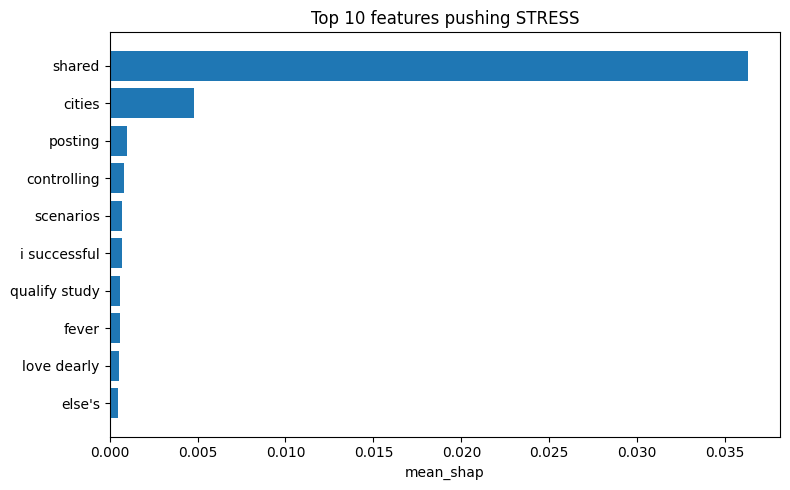

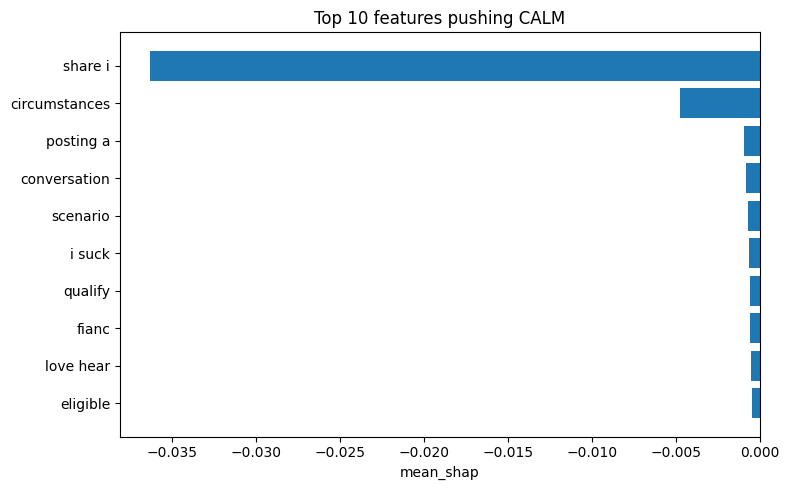


Saved PNGs on Drive:
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/combined_strat/best/shap_top10_positive.png
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/models/combined_strat/best/shap_top10_negative.png


In [ ]:
# ===========================================
# Inline plots in Colab: SHAP top 10 ±mean_shap
# ===========================================

# 1) Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# 2) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 3) Paths
ROOT = Path("/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final")
MODELS_DIR = ROOT / "models" / "combined_strat" / "best"
CSV_FP = MODELS_DIR / "shap_feature_importance_full.csv"

# 4) Load CSV
df = pd.read_csv(CSV_FP)
need = {"feature","mean_shap","mean_abs_shap"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing columns: {missing}")

# 5) Get top 10 by mean_shap for both directions
top_pos = df.sort_values("mean_shap", ascending=False).head(10).copy()
top_neg = df.sort_values("mean_shap", ascending=True).head(10).copy()

# 6) Print tables
print("Top 10 features pushing STRESS (by mean_shap):")
print(top_pos[["feature","mean_shap","mean_abs_shap"]].to_string(index=False))

print("\nTop 10 features pushing CALM (by mean_shap):")
print(top_neg[["feature","mean_shap","mean_abs_shap"]].to_string(index=False))

# 7) Plot inline and also save to Drive
# Positive figure
plt.figure(figsize=(8, 5))
features_pos = top_pos["feature"].astype(str).iloc[::-1]
values_pos = top_pos["mean_shap"].iloc[::-1]
plt.barh(features_pos, values_pos)
plt.xlabel("mean_shap")
plt.title("Top 10 features pushing STRESS")
plt.tight_layout()
plt.show()
OUT_POS_PNG = MODELS_DIR / "shap_top10_positive.png"
plt.figure(figsize=(8, 5))
plt.barh(features_pos, values_pos)
plt.xlabel("mean_shap")
plt.title("Top 10 features pushing STRESS")
plt.tight_layout()
plt.savefig(OUT_POS_PNG, dpi=200)
plt.close()

# Negative figure
plt.figure(figsize=(8, 5))
features_neg = top_neg["feature"].astype(str).iloc[::-1]
values_neg = top_neg["mean_shap"].iloc[::-1]
plt.barh(features_neg, values_neg)
plt.xlabel("mean_shap")
plt.title("Top 10 features pushing CALM")
plt.tight_layout()
plt.show()
OUT_NEG_PNG = MODELS_DIR / "shap_top10_negative.png"
plt.figure(figsize=(8, 5))
plt.barh(features_neg, values_neg)
plt.xlabel("mean_shap")
plt.title("Top 10 features pushing CALM")
plt.tight_layout()
plt.savefig(OUT_NEG_PNG, dpi=200)
plt.close()

print("\nSaved PNGs on Drive:")
print(" -", OUT_POS_PNG)
print(" -", OUT_NEG_PNG)


### Explaination
Here’s a concise, data-driven read on why your LinearSVC + probability calibration is doing so well on TF-IDF text:

High-dimensional sparse text favors margin-based learners
TF-IDF with 1–4 grams and 40k features creates a very high-dimensional, sparse space. Linear SVMs are strong here because they maximize the margin with a hinge loss, which often yields cleaner separation than logistic loss when many features are mostly zero. This typically improves recall at similar precision compared with LR in sparse NLP setups.

Class weighting + calibrated probabilities + tuned threshold work together
Your top SVC rows use class_weight={0:1, 1:2}. That tilts the decision toward catching positives, which you see as recall ≈ 0.94–0.95. CalibratedClassifierCV (sigmoid) converts SVM scores into usable probabilities. Then your pipeline picks thr = 0.45 based on validation F1, which is slightly below the default 0.5, further nudging recall up without collapsing precision. The result is F1 ≈ 0.861–0.862 and AUC ≈ 0.816.

Vectorizer settings reduce noise and highlight stable n-grams
The winning configs use max_features=40,000, min_df=3. That trims rare, noisy tokens and keeps consistent n-grams. Linear SVMs handle many correlated features well by focusing on support vectors near the boundary, which makes them robust to residual sparsity and collinearity.

Calibration helps SVC more than LR
LR is already probabilistic, so calibration adds less. SVC starts with margin scores, which can be poorly scaled. Platt scaling (sigmoid) or cross-validated calibration often improves the ranking quality for SVC, which is reflected in your AUC parity or slight edge and makes F1-oriented threshold search more effective.

Slight precision trade for large recall gain suits F1 on your data
Your use case seems recall-sensitive. SVC+Calib maintains precision ≈ 0.79 while boosting recall to ~0.94–0.95, which maximizes F1 under the dataset’s label balance and feature space. LR runs are very close, but SVC’s margin and calibration combo squeeze out a bit more recall at similar precision.

## Train with gemini

In [ ]:
# === Upload combined_strat_*_conversations.jsonl from Drive -> GCS bucket ===
# Bucket: gs://stress-llm     Location: us-central1
# Drive base_dir: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_gemini

# If running in Colab:
from google.colab import drive, auth as colab_auth
drive.mount("/content/drive")
colab_auth.authenticate_user()

import os
from pathlib import Path
from google.cloud import storage
from google.api_core.exceptions import Conflict, NotFound

PROJECT_ID   = "stress-llm"  # your project id (confirm this is correct)
BUCKET_NAME  = "stress-llm"  # your desired bucket name
BUCKET_LOC   = "us-central1"
DST_PREFIX   = "gemini-tuning"  # folder in bucket

# Drive source files
BASE_DIR = Path("/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_gemini")
SRC_TRAIN = BASE_DIR / "combined_strat_train_conversations.jsonl"
SRC_VALID = BASE_DIR / "combined_strat_test_conversations.jsonl"

# GCS destination object names
DST_TRAIN = f"{DST_PREFIX}/combined_strat_train_conversations.jsonl"
DST_VALID = f"{DST_PREFIX}/combined_strat_test_conversations.jsonl"

# ---- Sanity check ----
for p in (SRC_TRAIN, SRC_VALID):
    if not p.exists():
        raise FileNotFoundError(f"Missing source file: {p}")

# ---- Storage client ----
client = storage.Client(project=PROJECT_ID)

# ---- Create bucket if needed (uniform access) ----
try:
    bucket = client.get_bucket(BUCKET_NAME)
    print(f"Bucket exists: gs://{BUCKET_NAME}")
except NotFound:
    print(f"Creating bucket gs://{BUCKET_NAME} in {BUCKET_LOC} ...")
    bucket = client.bucket(BUCKET_NAME)
    bucket.location = BUCKET_LOC
    # Enforce uniform bucket-level access (recommended)
    bucket.iam_configuration.uniform_bucket_level_access_enabled = True
    bucket = client.create_bucket(bucket)
    print(f"Created bucket: gs://{BUCKET_NAME}")

# ---- Upload helper ----
def upload_jsonl(local_path: Path, blob_name: str):
    blob = bucket.blob(blob_name)
    # Set content type to JSON Lines
    blob.content_type = "application/json"
    blob.cache_control = "no-store"
    blob.upload_from_filename(local_path.as_posix())
    # Make sure metadata is saved
    blob.patch()
    print(f"Uploaded: {local_path.name} -> gs://{BUCKET_NAME}/{blob_name}")
    return f"gs://{BUCKET_NAME}/{blob_name}"

GCS_TRAIN_URI = upload_jsonl(SRC_TRAIN, DST_TRAIN)
GCS_VALID_URI = upload_jsonl(SRC_VALID, DST_VALID)

print("\nGCS URIs ready for tuning:")
print("  TRAIN:", GCS_TRAIN_URI)
print("  VALID:", GCS_VALID_URI)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.5/241.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 99.5 MB/s eta 0:00:00
ERROR: Operation cancelled by user


RuntimeError: No gold labels found. Add a 'label' field to evaluate.

Run the following cell to check if the google cloud is verified

In [ ]:
# If in Colab:
from google.colab import auth as colab_auth
colab_auth.authenticate_user()

from google.cloud import storage
import json
from pathlib import Path

PROJECT_ID = "stress-llm"  # your GCP project id
BUCKET     = "stress-llm"  # the bucket name you used when uploading
PREFIX     = "gemini-tuning"  # subfolder in the bucket

TRAIN_OBJ  = f"{PREFIX}/combined_strat_train_conversations.jsonl"
VALID_OBJ  = f"{PREFIX}/combined_strat_test_conversations.jsonl"

GCS_TRAIN_URI = f"gs://{BUCKET}/{TRAIN_OBJ}"
GCS_VALID_URI = f"gs://{BUCKET}/{VALID_OBJ}"

print("Expecting:")
print("  TRAIN:", GCS_TRAIN_URI)
print("  VALID:", GCS_VALID_URI)

client = storage.Client(project=PROJECT_ID)
bucket = client.bucket(BUCKET)

def blob_ok(blob_name: str, sample_lines=3):
    blob = bucket.blob(blob_name)
    if not blob.exists():
        print("❌ Missing object in GCS:", f"gs://{BUCKET}/{blob_name}")
        return False
    b = blob.download_as_bytes()
    if not b:
        print("❌ Empty object:", f"gs://{BUCKET}/{blob_name}")
        return False
    print("✅ Found:", f"gs://{BUCKET}/{blob_name}", f"(size={len(b):,} bytes)")
    # peek a few lines & parse as JSONL
    txt = b.decode("utf-8", errors="ignore").splitlines()
    shown = 0
    for line in txt:
        if not line.strip():
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError as e:
            print("❌ Not valid JSON on a line:", str(e))
            return False
        # quick schema check
        if not isinstance(obj, dict) or "contents" not in obj:
            print("❌ JSON object missing 'contents' key")
            return False
        if shown < sample_lines:
            print("  sample:", line[:200] + ("..." if len(line) > 200 else ""))
            shown += 1
        if shown >= sample_lines:
            break
    return True

ok_train = blob_ok(TRAIN_OBJ)
ok_valid = blob_ok(VALID_OBJ)


Expecting:
  TRAIN: gs://stress-llm/gemini-tuning/combined_strat_train_conversations.jsonl
  VALID: gs://stress-llm/gemini-tuning/combined_strat_test_conversations.jsonl
✅ Found: gs://stress-llm/gemini-tuning/combined_strat_train_conversations.jsonl (size=2,930,144 bytes)
  sample: {"contents": [{"role": "user", "parts": [{"text": "if you would like to donate, please go to: <url> my fundraising goal is high and i am struggling to reach it, so donations would be very much appreci...
  sample: {"contents": [{"role": "user", "parts": [{"text": "sleep_time is 08:50 AM, wake_time is 06:13 AM, sleep_duration is 6.5 hours, PSQI_score is 1, call_duration is 21.3 minutes, num_calls is 6, num_sms i...
  sample: {"contents": [{"role": "user", "parts": [{"text": "so what i am asking is someone or somebody's to help me with the rest of the repair cost. the repair is 575 dollars, i have about 200 of that current...
✅ Found: gs://stress-llm/gemini-tuning/combined_strat_test_conversations.jsonl (size=

# Fine-tuning

In [ ]:
# !pip install -U google-genai
from google import genai
from google.genai import types
import time

PROJECT_ID = "stress-llm"
LOCATION   = "us-central1"
BASE_MODEL = "gemini-2.5-flash"

GCS_TRAIN_URI = "gs://stress-llm/gemini-tuning/combined_strat_train_conversations.jsonl"
DISPLAY_NAME = "stress_v1_tuned"
EPOCHS       = 5

# ----------------------------------------------------------------------
# FIX: Remove the http_options line to let the client
# auto-negotiate the correct (likely v1beta) tuning API.
# ----------------------------------------------------------------------
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION,
    # http_options=types.HttpOptions(api_version="v1"),  # <-- REMOVED
)

# --- The rest of your script is correct ---
training_ds = types.TuningDataset(gcs_uri=GCS_TRAIN_URI)

tuning_job = client.tunings.tune(
    base_model=BASE_MODEL,
    training_dataset=training_ds,
    config=types.CreateTuningJobConfig(
        tuned_model_display_name=DISPLAY_NAME,
        epoch_count=EPOCHS,
    ),
)
print("Started tuning job:", tuning_job.name)

DONE = {"JOB_STATE_SUCCEEDED","JOB_STATE_FAILED","JOB_STATE_CANCELLED"}
while True:
    tj = client.tunings.get(name=tuning_job.name)
    print("State:", tj.state)
    if tj.state in DONE:
        break
    time.sleep(20)

if tj.state == "JOB_STATE_SUCCEEDED":
    print("✅ Tuned model id:", tj.tuned_model.model)
    print("✅ Endpoint:", tj.tuned_model.endpoint)
else:
    print("❌ Tuning did not succeed:", tj.state, getattr(tj, "error", ""))

Started tuning job: projects/345434891661/locations/us-central1/tuningJobs/1151797752183652352
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING


State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobState.JOB_STATE_RUNNING
State: JobStat

In [ ]:
# =========================
# Stress classifier eval (Gemini tuned endpoint) - head-50 option
# =========================

!pip -q install --upgrade google-genai scikit-learn tqdm

from google.colab import auth as colab_auth, drive
colab_auth.authenticate_user()
drive.mount("/content/drive")

import os, re, json, time, csv
from pathlib import Path
from typing import List, Dict, Tuple, Optional

from google import genai
from google.genai.types import HttpOptions

import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ---------------- User config ----------------
PROJECT_ID   = "stress-llm"
LOCATION     = "us-central1"
TUNED_ENDPOINT = "projects/345434891661/locations/us-central1/endpoints/1435846737154539520"

DATA_ROOT = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_gemini"
ROOT     = Path(DATA_ROOT)
TRAIN_FP = ROOT / "combined_strat_train_conversations.jsonl"
TEST_FP  = ROOT / "combined_strat_test_conversations.jsonl"

# Set to 50 to evaluate the first 50 rows from the test set.
# Use None to evaluate the full file.
HEAD_N = 50

OUT_DIR = ROOT / "eval_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Inference config
GEN_CONFIG = {
    "temperature": 0.0,
    "top_p": 1.0,
    "max_output_tokens": 4,
}

client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION,
    http_options=HttpOptions(api_version="v1"),
)

# ---------------- Helpers ----------------
def normalize_label_gold(s: str) -> str:
    """Gold labels: keep only 'yes' or 'no', else return '' to skip."""
    if not s:
        return ""
    s = s.strip().lower()
    if s.startswith("yes"):
        return "yes"
    if s.startswith("no"):
        return "no"
    return ""

def normalize_label_pred(s: str) -> str:
    """Predictions: coerce to strict binary. Defaults to 'no' if unclear."""
    if not s:
        return "no"
    s = s.strip().lower()
    if s.startswith("yes"):
        return "yes"
    if s.startswith("no"):
        return "no"
    if "yes" in s and "no" not in s:
        return "yes"
    if "no" in s and "yes" not in s:
        return "no"
    return "no"

def extract_pair(obj: Dict) -> Tuple[str, str]:
    """
    From one JSONL line like:
    {"contents":[{"role":"user","parts":[{"text":"..."}]},
                 {"role":"model","parts":[{"text":"yes"}]}]}
    return (user_text, gold_label)
    """
    contents = obj.get("contents", [])
    user_text, label = "", ""
    for item in contents:
        role = item.get("role", "")
        parts = item.get("parts", [])
        txt = parts[0]["text"] if parts and isinstance(parts, list) and "text" in parts[0] else ""
        if role == "user":
            user_text = txt
        elif role == "model":
            label = normalize_label_gold(txt)
    return user_text, label

def load_jsonl(path: Path, head_n: Optional[int] = None) -> List[Dict]:
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if head_n is not None and i >= head_n:
                break
            line = line.strip()
            if not line:
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                # soft fix trailing commas
                line = re.sub(r",\s*}", "}", line)
                line = re.sub(r",\s*]", "]", line)
                data.append(json.loads(line))
    return data

def classify(text: str) -> str:
    prompt = f"Classify this text as stressful (yes) or calm (no):\n{text}"
    resp = client.models.generate_content(
        model=TUNED_ENDPOINT,
        contents=prompt,
        config=GEN_CONFIG,
    )
    return normalize_label_pred(getattr(resp, "text", ""))

def evaluate(jsonl_path: Path, split_name: str = "eval", head_n: Optional[int] = None) -> Dict:
    rows = load_jsonl(jsonl_path, head_n=head_n)
    y_true, y_pred, raw_rows = [], [], []

    for obj in tqdm(rows, desc=f"Inferencing on {split_name}", total=len(rows)):
        text, label = extract_pair(obj)
        if not text or label not in {"yes", "no"}:
            continue  # skip malformed or unlabeled rows
        pred = classify(text)
        y_true.append(label)
        y_pred.append(pred)
        raw_rows.append({"text": text, "label": label, "pred": pred})

    # Quick sanity check
    unique_true = sorted(set(y_true))
    unique_pred = sorted(set(y_pred))
    print("Unique gold labels :", unique_true)
    print("Unique pred labels :", unique_pred)

    # Metrics
    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    prec = precision_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    rec = recall_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    cm = confusion_matrix(y_true, y_pred, labels=["yes", "no"]) if y_true else np.zeros((2,2), dtype=int)

    tag = f"{split_name}_head{head_n}" if head_n is not None else split_name

    # Save predictions CSV
    csv_fp = OUT_DIR / f"predictions_{tag}.csv"
    with open(csv_fp, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=["text", "label", "pred"])
        w.writeheader()
        w.writerows(raw_rows)

    # Save metrics JSON
    metrics = {
        "split": split_name,
        "head_n": head_n,
        "num_samples": len(y_true),
        "accuracy": acc,
        "precision_yes": prec,
        "recall_yes": rec,
        "f1_yes": f1,
        "labels_order_for_cm": ["yes", "no"],
        "confusion_matrix": cm.tolist(),
    }
    with open(OUT_DIR / f"metrics_{tag}.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    # Print report
    print(f"\n== {split_name.upper()} RESULTS ({'first '+str(head_n) if head_n else 'full'}) ==")
    print(f"Samples:   {len(y_true)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (positive=yes)")
    print(f"Recall:    {rec:.4f} (positive=yes)")
    print(f"F1-score:  {f1:.4f} (positive=yes)")
    print("\nConfusion matrix [rows=true, cols=pred], order=['yes','no']:\n", cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=["yes","no"], zero_division=0))
    print(f"\nSaved predictions to: {csv_fp}")
    print(f"Saved metrics to:     {OUT_DIR / f'metrics_{tag}.json'}")

    # Show a few mistakes
    mistakes = [r for r in raw_rows if r["label"] != r["pred"]]
    if mistakes:
        print("\nExamples of mistakes:")
        for r in mistakes[:5]:
            clip = r["text"][:120] + ("..." if len(r["text"]) > 120 else "")
            print(f"- label={r['label']} pred={r['pred']} | {clip}")
    else:
        print("\nNo mistakes found in the first pass.")
    return metrics

# ---------------- Run ----------------
# Evaluate the first 50 rows from TEST by default
test_metrics = evaluate(TEST_FP, split_name="test", head_n=HEAD_N)

# If you want to run the full test set later, do:
# test_full_metrics = evaluate(TEST_FP, split_name="test", head_n=None)

# If you also want train metrics (head-50), do:
# train_metrics = evaluate(TRAIN_FP, split_name="train", head_n=50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Inferencing on test: 100%|██████████| 50/50 [01:52<00:00,  2.25s/it]


Unique gold labels : ['no', 'yes']
Unique pred labels : ['no', 'yes']

== TEST RESULTS (first 50) ==
Samples:   50
Accuracy:  0.5200
Precision: 0.7333 (positive=yes)
Recall:    0.3548 (positive=yes)
F1-score:  0.4783 (positive=yes)

Confusion matrix [rows=true, cols=pred], order=['yes','no']:
 [[11 20]
 [ 4 15]]

Classification report:
              precision    recall  f1-score   support

         yes       0.73      0.35      0.48        31
          no       0.43      0.79      0.56        19

    accuracy                           0.52        50
   macro avg       0.58      0.57      0.52        50
weighted avg       0.62      0.52      0.51        50


Saved predictions to: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_gemini/eval_outputs/predictions_test_head50.csv
Saved metrics to:     /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_gemini/eval_outputs/metrics_test_head50.json

Examples of mistakes:
- labe

In [ ]:
# ===============================================
# Eval SVC model from GitHub (handles mixed_tokenize + filenames)
# Repo: github.com/tanlr20030801/Conversational-Based-Mental-Health-Chatbot
# Data: Dataset/combined_strat_{train,test}.jsonl
# Model: Dataset/stress_svc_v1/{tfidf_vectorizer.joblib, classifier.joblib}
# ===============================================

!pip -q install --upgrade scikit-learn tqdm joblib matplotlib

import os, re, json, csv, sys, subprocess
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import joblib
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# --------- Settings ---------
GIT_USER = "tanlr20030801"
REPO_NAME = "Conversational-Based-Mental-Health-Chatbot"
REPO_URL = f"https://github.com/{GIT_USER}/{REPO_NAME}.git"

BASE = Path("/content") / REPO_NAME            # Colab path; for local, change as needed
DATASET_DIR = BASE / "Dataset"
MODEL_DIR   = DATASET_DIR / "stress_svc_v1"

# Evaluate head or full
HEAD_N = 50   # set to None for full set

# --------- Clone / update ---------
def ensure_repo(repo_url: str, dest: Path) -> Path:
    if dest.exists():
        try:
            subprocess.run(["git", "-C", str(dest), "pull", "--ff-only"], check=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
            print("Repo updated (git pull).")
        except Exception as e:
            print("git pull failed, using existing copy:", e)
    else:
        subprocess.run(["git", "clone", "--depth", "1", repo_url, str(dest)], check=True)
        print("Repo cloned.")
    return dest

ensure_repo(REPO_URL, BASE)

# --------- Resolve dataset filenames ---------
def resolve_dataset_files(dataset_dir: Path) -> Tuple[Path, Path]:
    # Prefer the names you actually have
    candidates = {
        "train": ["combined_strat_train_conversations.jsonl"],
        "test":  ["combined_strat_test_conversations.jsonl"],
    }
    def pick(which: str) -> Path:
        for name in candidates[which]:
            p = dataset_dir / name
            if p.exists():
                return p
        raise FileNotFoundError(f"No {which} file found among: {candidates[which]} in {dataset_dir}")
    return pick("train"), pick("test")

try:
    TRAIN_FP, TEST_FP = resolve_dataset_files(DATASET_DIR)
except Exception as e:
    print("❌ Dataset lookup error:", e)
    print("Directory listing for Dataset/:")
    for p in sorted(DATASET_DIR.iterdir()):
        print(" -", p.name)
    raise

OUT_DIR = DATASET_DIR / "eval_outputs_svc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --------- Quick file check ---------
def check_file(path: Path):
    if path.exists():
        size_mb = path.stat().st_size / (1024*1024)
        print(f"✅ Found: {path.name} ({size_mb:.2f} MB)")
        with open(path, "r", encoding="utf-8") as f:
            for i in range(2):
                line = f.readline().strip()
                if not line:
                    break
                print(f"  Line {i+1}: {line[:200]}{'...' if len(line)>200 else ''}")
    else:
        print(f"❌ Not found:", path)

print("\nChecking dataset files...\n")
check_file(TRAIN_FP)
check_file(TEST_FP)

# --------- Provide mixed_tokenize BEFORE loading pickles ---------
# First, try to import from your model dir's inference.py if it exists.
def ensure_mixed_tokenize():
    # Add model dir to path to import inference.py if present
    inf_py = MODEL_DIR / "inference.py"
    if inf_py.exists():
        import importlib.util, types
        spec = importlib.util.spec_from_file_location("svc_infer_mod", str(inf_py))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)  # type: ignore
        if hasattr(mod, "mixed_tokenize"):
            print("Using mixed_tokenize from inference.py")
            # Make it visible as __main__.mixed_tokenize for pickle
            import __main__
            setattr(__main__, "mixed_tokenize", getattr(mod, "mixed_tokenize"))
            return

    # Fallback: define a reasonable tokenizer
    print("Using fallback mixed_tokenize (simple CN/EN split).")
    import re as _re
    def mixed_tokenize(text: str):
        if not text:
            return []
        # Basic lowercase, keep words, digits, and single CJK chars
        # Split into: english words/numbers, CJK chars, or punctuation
        tokens = _re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[\u4e00-\u9fff]|[^\s\w]", text.lower())
        return tokens
    # Expose under __main__ so unpickler can find __main__.mixed_tokenize
    import __main__
    setattr(__main__, "mixed_tokenize", mixed_tokenize)

ensure_mixed_tokenize()

# --------- Load vectorizer + classifier ---------
def load_artifacts(model_dir: Path):
    vec = model_dir / "tfidf_vectorizer.joblib"
    clf = model_dir / "classifier.joblib"
    if not vec.exists() or not clf.exists():
        raise FileNotFoundError("Expected tfidf_vectorizer.joblib and classifier.joblib in stress_svc_v1/")
    print("\nLoading artifacts...")
    vectorizer = joblib.load(vec)
    classifier = joblib.load(clf)
    print("Loaded:", vec.name, "and", clf.name)
    return vectorizer, classifier

vectorizer, classifier = load_artifacts(MODEL_DIR)

# --------- Stopwords (optional) ---------
def load_stopwords(dataset_dir: Path) -> set:
    sw = set()
    for name in ["english_stopwords.txt", "chinese_stopwords.txt"]:
        fp = dataset_dir / name
        if fp.exists():
            try:
                with open(fp, "r", encoding="utf-8") as f:
                    for line in f:
                        w = line.strip()
                        if w:
                            sw.add(w)
                print(f"Loaded stopwords from {name}: {len(sw)} total")
            except Exception as e:
                print(f"Could not read {name}: {e}")
    return sw

STOPWORDS = load_stopwords(DATASET_DIR)

def strip_stopwords(tokens: List[str], stopwords: set) -> List[str]:
    if not stopwords:
        return tokens
    return [t for t in tokens if not (t.isalpha() and t in stopwords)]

# --------- JSONL + extraction ---------
def load_jsonl(path: Path, head_n: Optional[int] = None) -> List[Dict]:
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if head_n is not None and i >= head_n:
                break
            line = line.strip()
            if not line:
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                line = re.sub(r",\s*}", "}", line)
                line = re.sub(r",\s*]", "]", line)
                data.append(json.loads(line))
    return data

def extract_pair(obj: Dict) -> Tuple[str, str]:
    contents = obj.get("contents", [])
    user_text, label = "", ""
    for item in contents:
        role = item.get("role", "")
        parts = item.get("parts", [])
        txt = parts[0]["text"] if parts and isinstance(parts, list) and "text" in parts[0] else ""
        if role == "user":
            user_text = txt
        elif role == "model":
            label = txt.strip().lower()
    label = "yes" if label.startswith("yes") else ("no" if label.startswith("no") else "")
    return user_text, label

# --------- Predict + eval ---------
def predict_labels(texts: List[str]) -> List[str]:
    import __main__  # ensure tokenizer still in scope
    tok_fn = getattr(__main__, "mixed_tokenize", None)
    preds = []
    for t in texts:
        tokens = tok_fn(t) if callable(tok_fn) else t.split()
        tokens = strip_stopwords(tokens, STOPWORDS)
        # Vectorizer expects strings, so join tokens back
        X = vectorizer.transform([" ".join(tokens)])
        y = classifier.predict(X)[0]
        y = str(y).strip().lower()
        preds.append("yes" if y.startswith("yes") else ("no" if y.startswith("no") else "no"))
    return preds

def evaluate(jsonl_path: Path, split_name: str = "eval", head_n: Optional[int] = None) -> Dict:
    rows = load_jsonl(jsonl_path, head_n=head_n)
    y_true, y_pred, raw_rows = [], [], []

    for obj in tqdm(rows, desc=f"Inferencing on {split_name}", total=len(rows)):
        text, label = extract_pair(obj)
        if not text or label not in {"yes", "no"}:
            continue
        pred = predict_labels([text])[0]
        y_true.append(label)
        y_pred.append(pred)
        raw_rows.append({"text": text, "label": label, "pred": pred})

    print("Unique gold labels :", sorted(set(y_true)))
    print("Unique pred labels :", sorted(set(y_pred)))

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    prec = precision_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    rec = recall_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    f1  = f1_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    cm  = confusion_matrix(y_true, y_pred, labels=["yes","no"]) if y_true else np.zeros((2,2), dtype=int)

    tag = f"{split_name}_head{head_n}" if head_n is not None else split_name
    tag = f"{tag}_svc_v1"

    csv_fp = OUT_DIR / f"predictions_{tag}.csv"
    with open(csv_fp, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=["text","label","pred"])
        w.writeheader()
        w.writerows(raw_rows)

    metrics = {
        "model_source": str(MODEL_DIR),
        "split": split_name,
        "head_n": head_n,
        "num_samples": len(y_true),
        "accuracy": acc,
        "precision_yes": prec,
        "recall_yes": rec,
        "f1_yes": f1,
        "labels_order_for_cm": ["yes","no"],
        "confusion_matrix": cm.tolist(),
    }
    with open(OUT_DIR / f"metrics_{tag}.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    print(f"\n== {split_name.upper()} RESULTS ({'first '+str(head_n) if head_n else 'full'}) [SVC v1] ==")
    print(f"Samples:   {len(y_true)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (positive=yes)")
    print(f"Recall:    {rec:.4f} (positive=yes)")
    print(f"F1-score:  {f1:.4f} (positive=yes)")
    print("\nConfusion matrix [rows=true, cols=pred], order=['yes','no']:\n", cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=["yes","no"], zero_division=0))
    print(f"\nSaved predictions to:", csv_fp)
    print(f"Saved metrics to:     {OUT_DIR / f'metrics_{tag}.json'}")

    mistakes = [r for r in raw_rows if r["label"] != r["pred"]]
    if mistakes:
        print("\nExamples of mistakes:")
        for r in mistakes[:5]:
            clip = r["text"][:120] + ("..." if len(r["text"]) > 120 else "")
            print(f"- label={r['label']} pred={r['pred']} | {clip}")
    else:
        print("\nNo mistakes found in the first pass.")
    return metrics

# --------- Run ---------
print("\nRunning head evaluation...")
test_head = evaluate(TEST_FP, split_name="test", head_n=HEAD_N)

print("\nRunning full evaluation...")
test_full = evaluate(TEST_FP, split_name="test", head_n=None)

# Optional: confusion matrix figure for full set
try:
    import matplotlib.pyplot as plt
    cm = np.array(test_full["confusion_matrix"])
    labels = test_full["labels_order_for_cm"]
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (SVC v1, full test)")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    fig_path = OUT_DIR / "confusion_matrix_test_svc_v1.png"
    plt.savefig(fig_path, dpi=150)
    plt.close()
    print("Saved confusion matrix PNG:", fig_path)
except Exception as e:
    print("Plot skipped:", e)


Repo updated (git pull).

Checking dataset files...

✅ Found: combined_strat_train_conversations.jsonl (2.79 MB)
  Line 1: {"contents": [{"role": "user", "parts": [{"text": "if you would like to donate, please go to: <url> my fundraising goal is high and i am struggling to reach it, so donations would be very much appreci...
  Line 2: {"contents": [{"role": "user", "parts": [{"text": "sleep_time is 08:50 AM, wake_time is 06:13 AM, sleep_duration is 6.5 hours, PSQI_score is 1, call_duration is 21.3 minutes, num_calls is 6, num_sms i...
✅ Found: combined_strat_test_conversations.jsonl (0.70 MB)
  Line 1: {"contents": [{"role": "user", "parts": [{"text": "i legitimately do not know anyone who has survived this, and i feel like i'm not even human any more. as i type this, i'm sobbing, because it's all j...
  Line 2: {"contents": [{"role": "user", "parts": [{"text": "i explained my situation without giving him how long i’ve been homeless but said i’d be back on my feet by december. that was

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.6.1 when using version 1.7.2. This might lead to breaking code or in

Loaded: tfidf_vectorizer.joblib and classifier.joblib
Loaded stopwords from english_stopwords.txt: 553 total
Loaded stopwords from chinese_stopwords.txt: 1395 total

Running head evaluation...


Inferencing on test: 100%|██████████| 50/50 [00:00<00:00, 63.91it/s]


Unique gold labels : ['no', 'yes']
Unique pred labels : ['no']

== TEST RESULTS (first 50) [SVC v1] ==
Samples:   50
Accuracy:  0.3800
Precision: 0.0000 (positive=yes)
Recall:    0.0000 (positive=yes)
F1-score:  0.0000 (positive=yes)

Confusion matrix [rows=true, cols=pred], order=['yes','no']:
 [[ 0 31]
 [ 0 19]]

Classification report:
              precision    recall  f1-score   support

         yes       0.00      0.00      0.00        31
          no       0.38      1.00      0.55        19

    accuracy                           0.38        50
   macro avg       0.19      0.50      0.28        50
weighted avg       0.14      0.38      0.21        50


Saved predictions to: /content/Conversational-Based-Mental-Health-Chatbot/Dataset/eval_outputs_svc/predictions_test_head50_svc_v1.csv
Saved metrics to:     /content/Conversational-Based-Mental-Health-Chatbot/Dataset/eval_outputs_svc/metrics_test_head50_svc_v1.json

Examples of mistakes:
- label=yes pred=no | i legitimately do not 

Inferencing on test: 100%|██████████| 1461/1461 [00:09<00:00, 160.55it/s]


Unique gold labels : ['no', 'yes']
Unique pred labels : ['no']

== TEST RESULTS (full) [SVC v1] ==
Samples:   1461
Accuracy:  0.3046
Precision: 0.0000 (positive=yes)
Recall:    0.0000 (positive=yes)
F1-score:  0.0000 (positive=yes)

Confusion matrix [rows=true, cols=pred], order=['yes','no']:
 [[   0 1016]
 [   0  445]]

Classification report:
              precision    recall  f1-score   support

         yes       0.00      0.00      0.00      1016
          no       0.30      1.00      0.47       445

    accuracy                           0.30      1461
   macro avg       0.15      0.50      0.23      1461
weighted avg       0.09      0.30      0.14      1461


Saved predictions to: /content/Conversational-Based-Mental-Health-Chatbot/Dataset/eval_outputs_svc/predictions_test_svc_v1.csv
Saved metrics to:     /content/Conversational-Based-Mental-Health-Chatbot/Dataset/eval_outputs_svc/metrics_test_svc_v1.json

Examples of mistakes:
- label=yes pred=no | i legitimately do not know any

In [ ]:
# ==========================================================
# Evaluate fine-tuned Gemini endpoint on conversation JSONL
# Source data: GitHub repo (no Drive needed)
# Prints metrics only: Accuracy, Precision, Recall, F1, Confusion Matrix
# ==========================================================

!pip -q install --upgrade google-genai scikit-learn tqdm

from google.colab import auth as colab_auth
colab_auth.authenticate_user()

import os, re, json, subprocess
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from google import genai
from google.genai.types import HttpOptions

# ---------------- User config ----------------
PROJECT_ID   = "stress-llm"
LOCATION     = "us-central1"
# Your tuned endpoint (kept from earlier messages)
TUNED_ENDPOINT = "projects/345434891661/locations/us-central1/endpoints/1435846737154539520"

# GitHub repo with dataset
GIT_USER  = "tanlr20030801"
REPO_NAME = "Conversational-Based-Mental-Health-Chatbot"
REPO_URL  = f"https://github.com/{GIT_USER}/{REPO_NAME}.git"

# Prefer conversation files; fall back to non-suffixed ones if needed
CANDIDATES = {
    "train": ["combined_strat_train_conversations.jsonl", "combined_strat_train.jsonl"],
    "test":  ["combined_strat_test_conversations.jsonl",  "combined_strat_test.jsonl"],
}

# Evaluate the first N examples; set to None for full test set
HEAD_N = None

# Inference config for Gemini
GEN_CONFIG = {
    "temperature": 0.0,
    "top_p": 1.0,
    "max_output_tokens": 4,
}

# ---------------- Clone or update the repo ----------------
BASE = Path("/content") / REPO_NAME
if BASE.exists():
    try:
        subprocess.run(["git", "-C", str(BASE), "pull", "--ff-only"], check=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        print("Repo updated (git pull).")
    except Exception as e:
        print("git pull failed; using existing copy:", e)
else:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(BASE)], check=True)
    print("Repo cloned.")

DATASET_DIR = BASE / "Dataset"

def resolve_dataset_file(which: str) -> Path:
    for name in CANDIDATES[which]:
        p = DATASET_DIR / name
        if p.exists():
            return p
    raise FileNotFoundError(
        f"No {which} file found among {CANDIDATES[which]} in {DATASET_DIR}"
    )

TRAIN_FP = resolve_dataset_file("train")
TEST_FP  = resolve_dataset_file("test")
print("Using files:")
print("  Train:", TRAIN_FP.name)
print("  Test :", TEST_FP.name)

# ---------------- GenAI client (Vertex) ----------------
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION,
    http_options=HttpOptions(api_version="v1"),
)

# ---------------- Helpers ----------------
def normalize_label_gold(s: str) -> str:
    """Gold labels must be 'yes' or 'no'."""
    if not s:
        return ""
    s = s.strip().lower()
    if s.startswith("yes"):
        return "yes"
    if s.startswith("no"):
        return "no"
    return ""

def normalize_label_pred(s: str) -> str:
    """Coerce model output to strict 'yes'/'no' to keep sklearn binary."""
    if not s:
        return "no"
    s = s.strip().lower()
    if s.startswith("yes"):
        return "yes"
    if s.startswith("no"):
        return "no"
    if "yes" in s and "no" not in s:
        return "yes"
    if "no" in s and "yes" not in s:
        return "no"
    return "no"

def load_jsonl(path: Path, head_n: Optional[int] = None) -> List[Dict]:
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if head_n is not None and i >= head_n:
                break
            line = line.strip()
            if not line:
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                # Soft fix trailing commas if any
                line = re.sub(r",\s*}", "}", line)
                line = re.sub(r",\s*]", "]", line)
                data.append(json.loads(line))
    return data

def extract_pair(obj: Dict) -> Tuple[str, str]:
    """
    From one JSONL line like:
    {"contents":[{"role":"user","parts":[{"text":"..."}]},
                 {"role":"model","parts":[{"text":"yes"}]}]}
    return (user_text, gold_label)
    """
    contents = obj.get("contents", [])
    user_text, label = "", ""
    for item in contents:
        role = item.get("role", "")
        parts = item.get("parts", [])
        txt = parts[0]["text"] if parts and isinstance(parts, list) and "text" in parts[0] else ""
        if role == "user":
            user_text = txt
        elif role == "model":
            label = normalize_label_gold(txt)
    return user_text, label

def classify(text: str) -> str:
    prompt = f"Classify this text as stressful (yes) or calm (no):\n{text}"
    resp = client.models.generate_content(
        model=TUNED_ENDPOINT,
        contents=prompt,
        config=GEN_CONFIG,
    )
    return normalize_label_pred(getattr(resp, "text", ""))

def evaluate(jsonl_path: Path, split_name: str = "eval", head_n: Optional[int] = None):
    rows = load_jsonl(jsonl_path, head_n=head_n)
    y_true, y_pred = [], []

    for obj in tqdm(rows, desc=f"Inferencing on {split_name}", total=len(rows)):
        text, label = extract_pair(obj)
        if not text or label not in {"yes", "no"}:
            continue
        pred = classify(text)
        y_true.append(label)
        y_pred.append(pred)

    # Metrics (binary, pos=yes)
    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    prec = precision_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    rec = recall_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    f1  = f1_score(y_true, y_pred, pos_label="yes", zero_division=0) if y_true else 0.0
    cm  = confusion_matrix(y_true, y_pred, labels=["yes","no"]) if y_true else np.zeros((2,2), dtype=int)

    # Print metrics only
    print(f"\n== {split_name.upper()} METRICS ({'first '+str(head_n) if head_n else 'full'}) [tuned endpoint] ==")
    print(f"Samples:   {len(y_true)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (positive=yes)")
    print(f"Recall:    {rec:.4f} (positive=yes)")
    print(f"F1-score:  {f1:.4f} (positive=yes)")
    print("\nConfusion matrix [rows=true, cols=pred], order=['yes','no']:\n", cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=["yes","no"], zero_division=0))

    return {
        "split": split_name,
        "head_n": head_n,
        "num_samples": len(y_true),
        "accuracy": acc,
        "precision_yes": prec,
        "recall_yes": rec,
        "f1_yes": f1,
        "labels_order_for_cm": ["yes","no"],
        "confusion_matrix": cm.tolist(),
    }

# ---------------- Run ----------------
test_metrics = evaluate(TEST_FP, split_name="test", head_n=HEAD_N)


Repo updated (git pull).
Using files:
  Train: combined_strat_train_conversations.jsonl
  Test : combined_strat_test_conversations.jsonl


Inferencing on test: 100%|██████████| 1461/1461 [32:18<00:00,  1.33s/it]


== TEST METRICS (full) [tuned endpoint] ==
Samples:   1461
Accuracy:  0.5161
Precision: 0.8351 (positive=yes)
Recall:    0.3789 (positive=yes)
F1-score:  0.5213 (positive=yes)

Confusion matrix [rows=true, cols=pred], order=['yes','no']:
 [[385 631]
 [ 76 369]]

Classification report:
              precision    recall  f1-score   support

         yes       0.84      0.38      0.52      1016
          no       0.37      0.83      0.51       445

    accuracy                           0.52      1461
   macro avg       0.60      0.60      0.52      1461
weighted avg       0.69      0.52      0.52      1461



Generating plot...


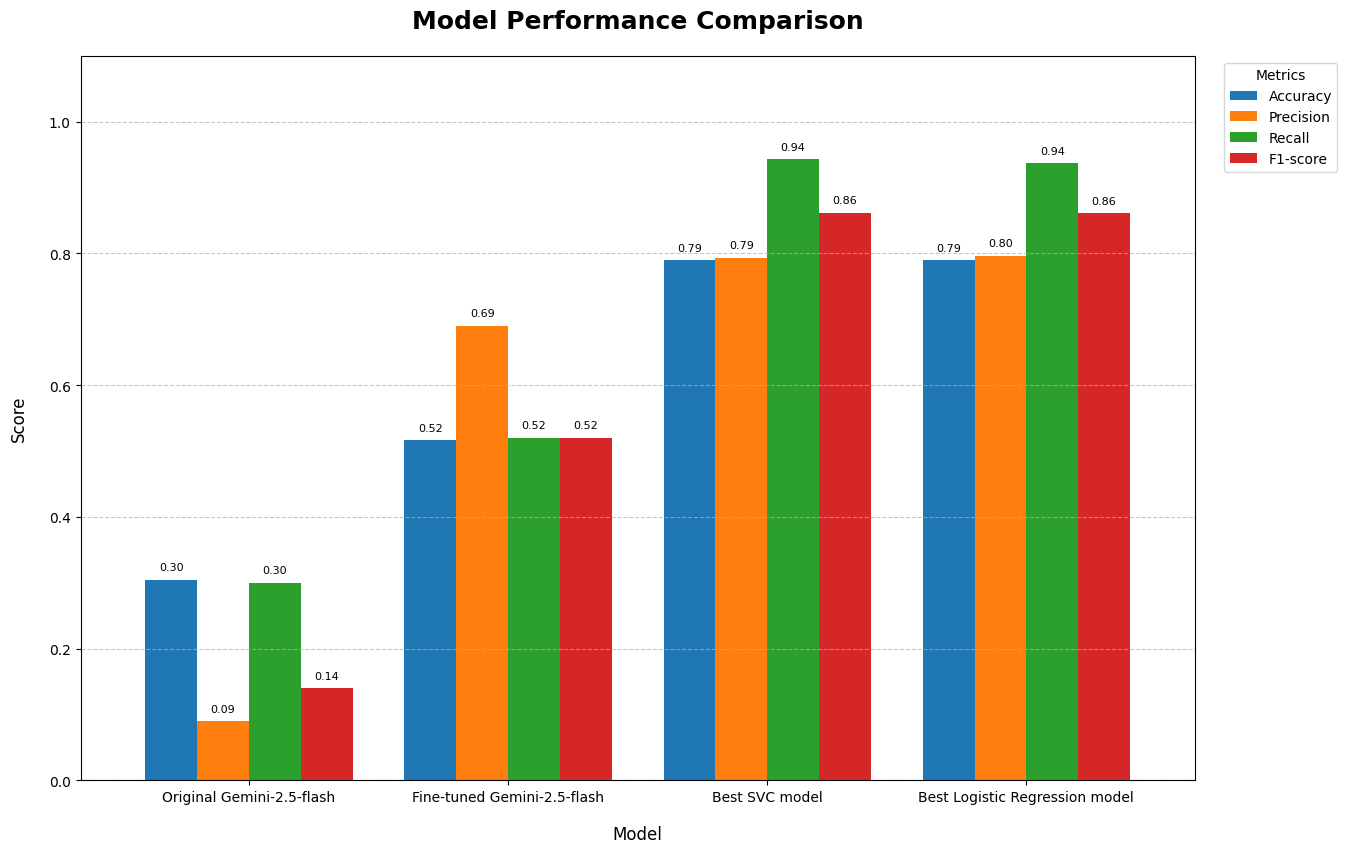

Plot generation complete.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Define the data
# We use the 'weighted avg' for the Gemini models as requested.
data = {
    'Model': [
        'Original Gemini-2.5-flash',
        'Fine-tuned Gemini-2.5-flash',
        'Best SVC model',
        'Best Logistic Regression model'
    ],
    'Accuracy': [0.3046, 0.5161, 0.7899, 0.7899],
    'Precision': [0.09, 0.69, 0.7937, 0.7967],
    'Recall': [0.30, 0.52, 0.9429, 0.9370],
    'F1-score': [0.14, 0.52, 0.8619, 0.8611]
}

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Set the 'Model' column as the index, which is better for plotting
df.set_index('Model', inplace=True)

# 2. Create the grouped bar chart
# 'kind='bar'' creates a bar chart
# 'figsize' sets the window size
# 'rot=0' keeps the x-axis labels horizontal
ax = df.plot(
    kind='bar',
    figsize=(16, 9),
    width=0.8, # Width of the groups
    rot=0,
    fontsize=10
)

# 3. Customize the plot
ax.set_title('Model Performance Comparison', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12, labelpad=15)
ax.set_xlabel('Model', fontsize=12, labelpad=15)

# Set the y-axis limit from 0 to 1 (or slightly above)
ax.set_ylim(0, 1.1)

# Add a horizontal grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",  # Format the number to 2 decimal places
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=8,
        color='black'
    )

# Customize the legend
# 'bbox_to_anchor' moves the legend outside the plot
ax.legend(
    title='Metrics',
    bbox_to_anchor=(1.02, 1.0), # Position legend outside, to the top right
    loc='upper left',
    # ncol=4, # Display metrics vertically
    fontsize=10
)

# Adjust layout to prevent labels from being cut off
plt.tight_layout(rect=[0, 0, 0.85, 0.96]) # Adjust rect to make space for title and legend

# 4. Display the plot
print("Generating plot...")
plt.show()
print("Plot generation complete.")